In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print(" Libraries loaded!")

 Libraries loaded!


In [3]:
df = pd.read_csv('../data/processed/all_stocks_featured.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol','Date']).reset_index(drop=True)

# Pivot close prices
close_prices = df.pivot_table(
    index='Date', columns='Symbol', values='Close'
)
close_prices = close_prices.dropna(
    axis=1, thresh=int(len(close_prices)*0.8))
close_prices = close_prices.fillna(method='ffill')

# Daily returns
returns = close_prices.pct_change().dropna()

print(f" Data loaded!")
print(f"Stocks: {len(returns.columns)}")
print(f"Trading days: {len(returns)}")

 Data loaded!
Stocks: 47
Trading days: 2099


In [4]:
def calculate_risk_metrics(returns_series, risk_free=0.06):
    
    # Annual return
    annual_return = returns_series.mean() * 252
    
    # Annual volatility
    annual_vol = returns_series.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (annual_return - risk_free) / annual_vol
    
    # Sortino Ratio (only downside risk)
    downside = returns_series[returns_series < 0]
    downside_std = downside.std() * np.sqrt(252)
    sortino = (annual_return - risk_free) / downside_std
    
    # Maximum Drawdown
    cum_returns = (1 + returns_series).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown    = (cum_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Value at Risk (95%)
    var_95 = np.percentile(returns_series, 5)
    
    # Beta (vs equal weight market)
    market_returns = returns.mean(axis=1)
    cov   = np.cov(returns_series, market_returns)[0][1]
    var_m = np.var(market_returns)
    beta  = cov / var_m
    
    return {
        'Annual Return (%)':   round(annual_return * 100, 2),
        'Annual Volatility (%)': round(annual_vol  * 100, 2),
        'Sharpe Ratio':        round(sharpe,        2),
        'Sortino Ratio':       round(sortino,        2),
        'Max Drawdown (%)':    round(max_drawdown * 100, 2),
        'VaR 95% (%)':         round(var_95       * 100, 2),
        'Beta':                round(beta,          2),
    }

print(" Risk metrics function ready!")

 Risk metrics function ready!


In [5]:
risk_data = {}
for symbol in returns.columns:
    risk_data[symbol] = calculate_risk_metrics(returns[symbol])

risk_df = pd.DataFrame(risk_data).T
risk_df = risk_df.sort_values('Sharpe Ratio', ascending=False)

print("TOP 10 STOCKS BY SHARPE RATIO:")
print("=" * 75)
print(risk_df.head(10).to_string())
print("\nBOTTOM 5 STOCKS BY SHARPE RATIO:")
print("=" * 75)
print(risk_df.tail(5).to_string())

TOP 10 STOCKS BY SHARPE RATIO:
            Annual Return (%)  Annual Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  VaR 95% (%)  Beta
BAJAJFINSV              36.59                  34.29          0.89           1.24            -58.59        -2.90  1.17
BRITANNIA               29.73                  32.35          0.73           0.81            -69.02        -2.29  0.70
BAJFINANCE              41.57                  49.90          0.71           0.68            -93.28        -3.42  1.36
SHREECEM                27.10                  29.83          0.71           1.14            -36.90        -2.77  0.92
HINDUNILVR              20.70                  24.53          0.60           1.03            -25.10        -2.13  0.59
ADANIPORTS              28.53                  38.27          0.59           0.86            -53.69        -3.34  1.22
TITAN                   25.55                  33.77          0.58           0.84            -41.73        -2.88  0.94
MARUTI           

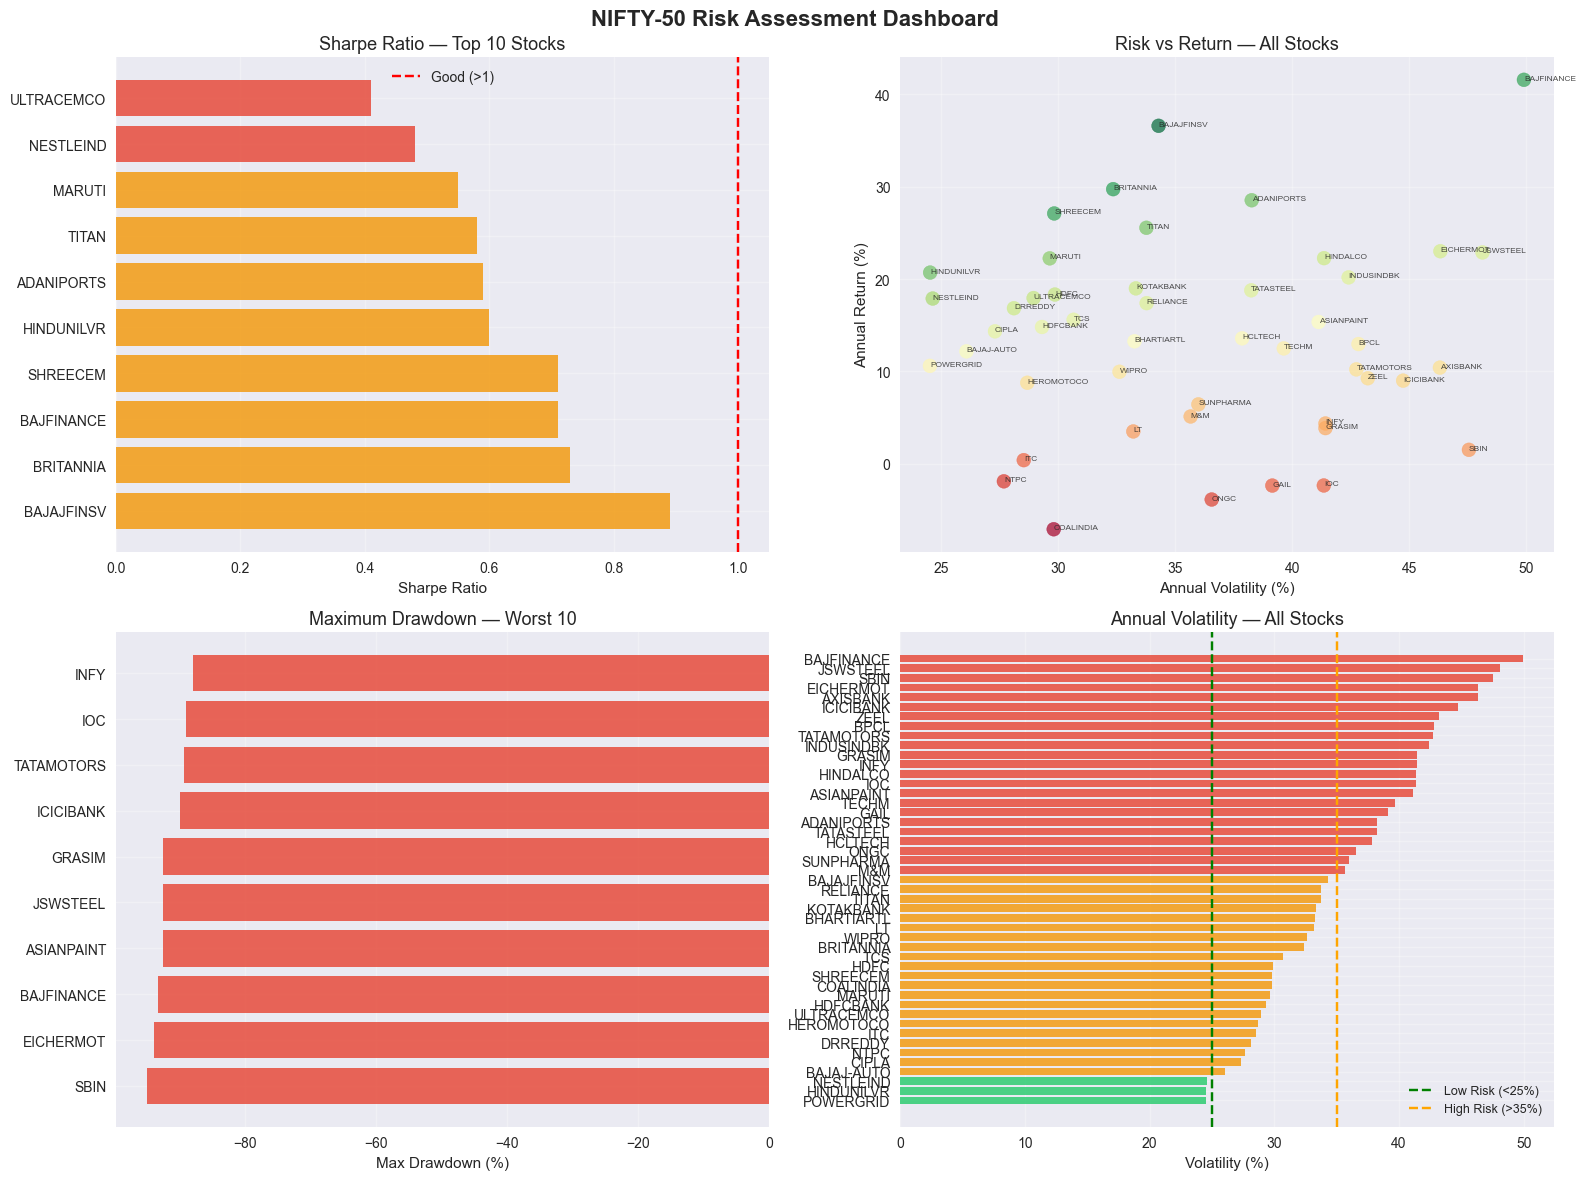

 Risk dashboard saved!


In [6]:
top10 = risk_df.head(10).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sharpe Ratio
colors = ['#2ECC71' if x > 1 else '#F39C12' if x > 0.5 
          else '#E74C3C' for x in top10['Sharpe Ratio']]
axes[0,0].barh(top10.index, top10['Sharpe Ratio'], 
               color=colors, alpha=0.85)
axes[0,0].axvline(x=1, color='red', linestyle='--', 
                  label='Good (>1)')
axes[0,0].set_title('Sharpe Ratio — Top 10 Stocks', fontsize=13)
axes[0,0].set_xlabel('Sharpe Ratio')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Risk vs Return
axes[0,1].scatter(
    risk_df['Annual Volatility (%)'],
    risk_df['Annual Return (%)'],
    c=risk_df['Sharpe Ratio'],
    cmap='RdYlGn', s=100, alpha=0.7
)
for idx, row in risk_df.iterrows():
    axes[0,1].annotate(
        idx,
        (row['Annual Volatility (%)'], row['Annual Return (%)']),
        fontsize=6, alpha=0.8
    )
axes[0,1].set_title('Risk vs Return — All Stocks', fontsize=13)
axes[0,1].set_xlabel('Annual Volatility (%)')
axes[0,1].set_ylabel('Annual Return (%)')
axes[0,1].grid(True, alpha=0.3)

# 3. Max Drawdown
worst10 = risk_df.nsmallest(10, 'Max Drawdown (%)')
axes[1,0].barh(worst10.index, worst10['Max Drawdown (%)'],
               color='#E74C3C', alpha=0.85)
axes[1,0].set_title('Maximum Drawdown — Worst 10', fontsize=13)
axes[1,0].set_xlabel('Max Drawdown (%)')
axes[1,0].grid(True, alpha=0.3)

# 4. Volatility comparison
vol_sorted = risk_df.sort_values(
    'Annual Volatility (%)', ascending=True)
colors_vol = ['#2ECC71' if x < 25 else '#F39C12' if x < 35 
              else '#E74C3C' for x in vol_sorted['Annual Volatility (%)']]
axes[1,1].barh(vol_sorted.index, 
               vol_sorted['Annual Volatility (%)'],
               color=colors_vol, alpha=0.85)
axes[1,1].axvline(x=25, color='green',  linestyle='--', 
                  label='Low Risk (<25%)')
axes[1,1].axvline(x=35, color='orange', linestyle='--', 
                  label='High Risk (>35%)')
axes[1,1].set_title('Annual Volatility — All Stocks', fontsize=13)
axes[1,1].set_xlabel('Volatility (%)')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('NIFTY-50 Risk Assessment Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/risk_dashboard.png', dpi=150)
plt.show()
print(" Risk dashboard saved!")

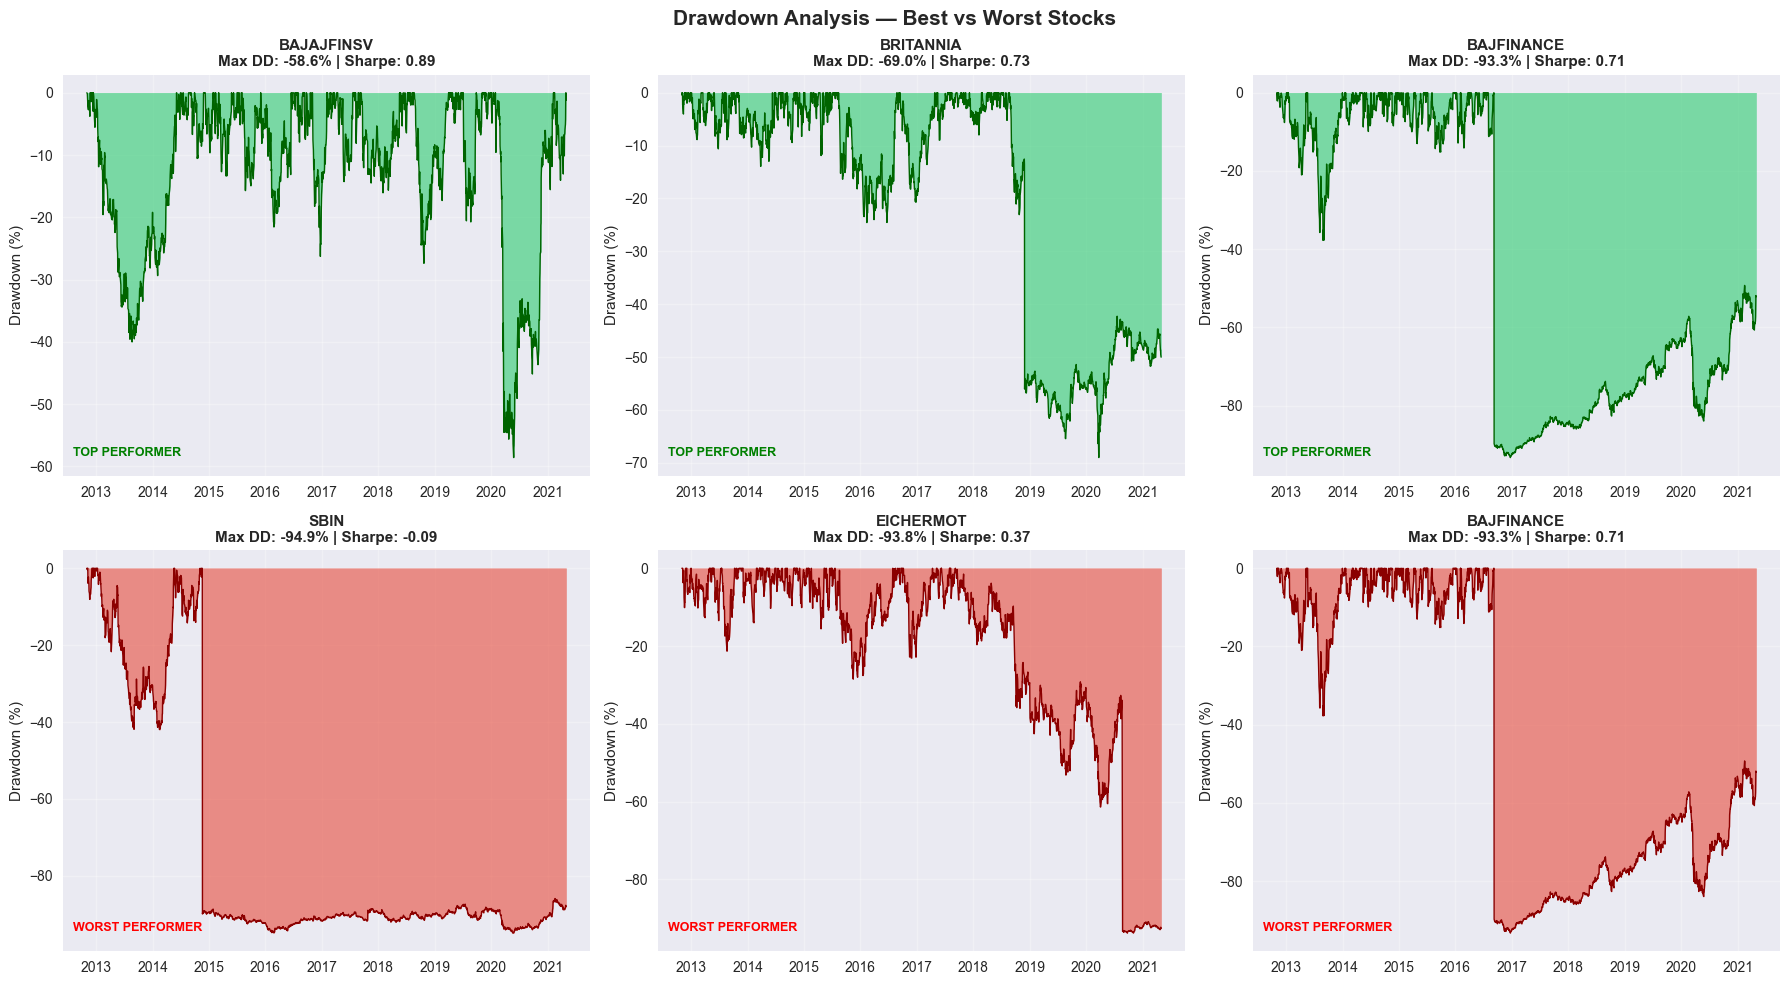

In [7]:
# Plot drawdown for top 3 and worst 3 stocks
top3    = risk_df.head(3).index.tolist()
worst3  = risk_df.nsmallest(3, 'Max Drawdown (%)').index.tolist()
stocks  = top3 + worst3

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, symbol in enumerate(stocks):
    cum_ret     = (1 + returns[symbol]).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown    = (cum_ret - rolling_max) / rolling_max * 100
    
    axes[i].fill_between(drawdown.index, drawdown, 0,
                         alpha=0.6,
                         color='#2ECC71' if i < 3 else '#E74C3C')
    axes[i].plot(drawdown.index, drawdown,
                 color='darkgreen' if i < 3 else 'darkred',
                 linewidth=1)
    
    max_dd = risk_df.loc[symbol, 'Max Drawdown (%)']
    sharpe = risk_df.loc[symbol, 'Sharpe Ratio']
    
    axes[i].set_title(
        f'{symbol}\nMax DD: {max_dd:.1f}% | Sharpe: {sharpe:.2f}',
        fontsize=11, fontweight='bold'
    )
    axes[i].set_ylabel('Drawdown (%)')
    axes[i].grid(True, alpha=0.3)
    
    label = 'TOP PERFORMER' if i < 3 else 'WORST PERFORMER'
    color = 'green'         if i < 3 else 'red'
    axes[i].text(0.02, 0.05, label,
                 transform=axes[i].transAxes,
                 fontsize=9, color=color, fontweight='bold')

plt.suptitle('Drawdown Analysis — Best vs Worst Stocks',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/drawdown_analysis.png', dpi=150)
plt.show()

In [8]:
# Load portfolio weights
port_df = pd.read_csv('../data/processed/portfolio_weights.csv')
port_df = port_df.set_index('Stock')

# Filter to available stocks
available = [s for s in port_df.index if s in returns.columns]
port_df   = port_df.loc[available]
ret_port  = returns[available]

portfolios = {
    'Conservative': port_df['Conservative'].values / 100,
    'Balanced':     port_df['Balanced'].values     / 100,
    'Aggressive':   port_df['Aggressive'].values   / 100,
}

print("=" * 65)
print("      PORTFOLIO RISK COMPARISON")
print("=" * 65)
print(f"  {'Portfolio':<20} {'Return':>8} {'Risk':>8} "
      f"{'Sharpe':>8} {'Max DD':>10}")
print("-" * 65)

port_metrics = {}
for name, weights in portfolios.items():
    # Normalize weights
    w   = weights / weights.sum()
    pr  = ret_port.dot(w)
    m   = calculate_risk_metrics(pr)
    port_metrics[name] = m
    print(f"  {name:<20} "
          f"{m['Annual Return (%)']:>7.1f}% "
          f"{m['Annual Volatility (%)']:>7.1f}% "
          f"{m['Sharpe Ratio']:>8.2f} "
          f"{m['Max Drawdown (%)']:>9.1f}%")

print("=" * 65)

      PORTFOLIO RISK COMPARISON
  Portfolio              Return     Risk   Sharpe     Max DD
-----------------------------------------------------------------
  Conservative            20.2%    15.6%     0.91     -27.5%
  Balanced                28.3%    19.4%     1.15     -37.8%
  Aggressive              33.8%    26.6%     1.05     -45.8%


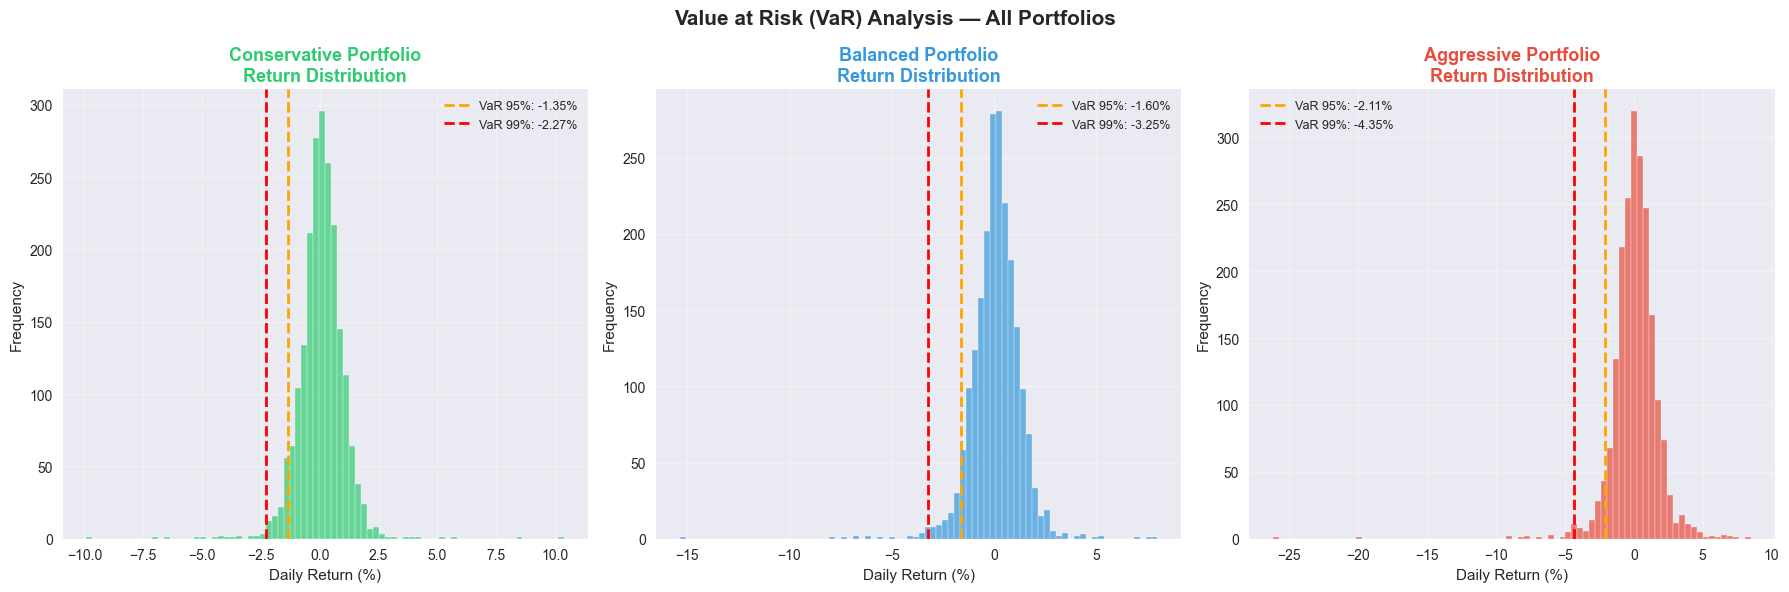

 VaR analysis saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#2ECC71', '#3498DB', '#E74C3C']

for i, (name, weights) in enumerate(portfolios.items()):
    w  = weights / weights.sum()
    pr = ret_port.dot(w)
    
    axes[i].hist(pr * 100, bins=80,
                 color=colors[i], alpha=0.7,
                 edgecolor='white')
    
    var_95 = np.percentile(pr * 100, 5)
    var_99 = np.percentile(pr * 100, 1)
    
    axes[i].axvline(var_95, color='orange', linewidth=2,
                    linestyle='--',
                    label=f'VaR 95%: {var_95:.2f}%')
    axes[i].axvline(var_99, color='red',    linewidth=2,
                    linestyle='--',
                    label=f'VaR 99%: {var_99:.2f}%')
    
    axes[i].set_title(f'{name} Portfolio\nReturn Distribution',
                      fontsize=13, fontweight='bold',
                      color=colors[i])
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Value at Risk (VaR) Analysis — All Portfolios',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/var_analysis.png', dpi=150)
plt.show()
print(" VaR analysis saved!")

In [11]:
risk_df.to_csv('../data/processed/risk_metrics.csv')
print(" Risk metrics saved!")

port_risk_df = pd.DataFrame(port_metrics).T
port_risk_df.to_csv('../data/processed/portfolio_risk.csv')
print(" Portfolio risk saved!")

print("\n" + "="*50)
print("      RISK MODULE SUMMARY")
print("="*50)
print(f"  Stocks analyzed:      {len(risk_df)}")
print(f"  Best Sharpe Stock:    {risk_df.index[0]} "
      f"({risk_df.iloc[0]['Sharpe Ratio']})")
print(f"  Most Volatile Stock:  "
      f"{risk_df['Annual Volatility (%)'].idxmax()}")
print(f"  Least Volatile Stock: "
      f"{risk_df['Annual Volatility (%)'].idxmin()}")
print("="*50)
print("\n Risk Assessment Module Complete!")

 Risk metrics saved!
 Portfolio risk saved!

      RISK MODULE SUMMARY
  Stocks analyzed:      47
  Best Sharpe Stock:    BAJAJFINSV (0.89)
  Most Volatile Stock:  BAJFINANCE
  Least Volatile Stock: POWERGRID

 Risk Assessment Module Complete!
